In [2]:
import pandas as pd
import numpy as np
import wfdb
import matplotlib.pyplot as plt
import neurokit2 as nk

In [3]:
#-----------LOAD DATA-----------#

def load_record(path):
    record = wfdb.rdsamp(path)
    signal = record[0]
    meta = record[1]
    return signal, meta

In [4]:
#------------------IMPORT DATA FROM CSV FILE-------------------#

df = pd.read_csv('data/ptb-xl/ptbxl_database.csv')
df.head()


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [5]:
base_path = "data/ptb-xl/"

row = df.iloc[0]

path = base_path + row["filename_hr"]  # for 500 Hz
print(path)

signal, meta = load_record(path)
print(signal.shape)

data/ptb-xl/records500/00000/00001_hr
(5000, 12)


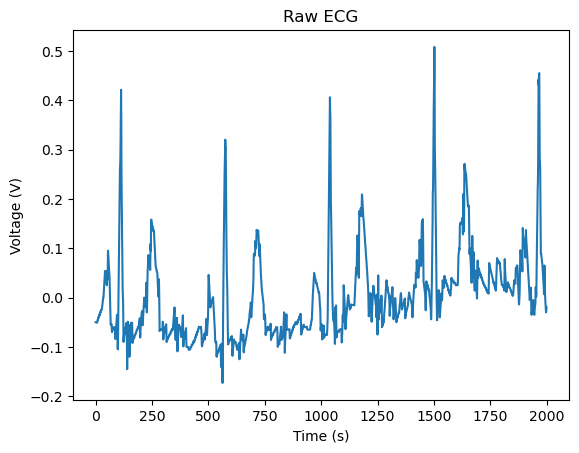

In [6]:
#-----------PLOTTING-----------#

import matplotlib.pyplot as plt

plt.plot(signal[:2000, 1])  # lead II
plt.title("Raw ECG")
plt.xlabel('Time (s)')      
plt.ylabel('Voltage (V)') 
plt.show()

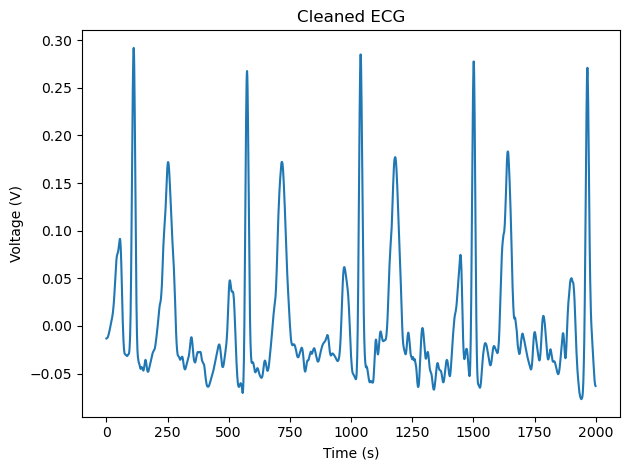

In [7]:
#--------------CLEANING DATA----------------#

import neurokit2 as nk

def clean_ecg(signal, fs):
    """Accepts (5000,12) or (12,5000), always returns (12, 5000)."""
    # ensure leads-first shape
    if signal.shape[0] > signal.shape[1]:   # (5000, 12) → transpose
        signal = signal.T                    # now (12, 5000)
    
    cleaned = []
    for i in range(signal.shape[0]):        # iterate over 12 leads
        cleaned_lead = nk.ecg_clean(signal[i], sampling_rate=fs)
        cleaned.append(cleaned_lead)
    
    return np.array(cleaned)                # (12, 5000)

#-----visualize cleaned signal-----#

signal, meta = load_record(path)
cleaned_sig = clean_ecg(signal, 500)
plt.plot(cleaned_sig[1][:2000])
plt.title('Cleaned ECG')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.tight_layout()
plt.show()

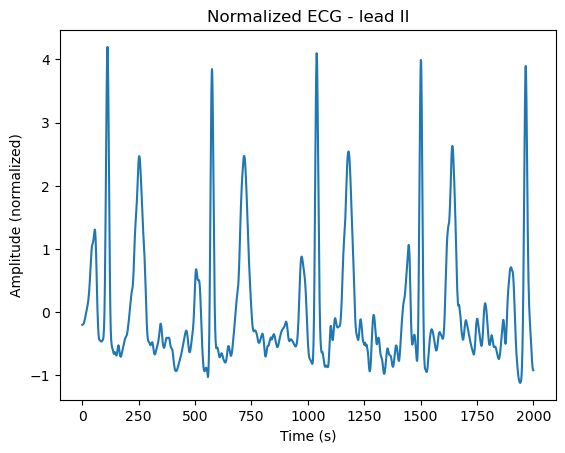

In [8]:
#-----------NORMALIZATION-----------#

def normalize_ecg(signal):
    mean = np.mean(signal, axis=1, keepdims=True)
    std = np.std(signal, axis=1, keepdims=True)
    return (signal-mean)/(std + 1e-8)

#-----visualize normalizedsignal-----#

signal, meta = load_record(path)
normalized_sig = normalize_ecg(cleaned_sig)
plt.plot(normalized_sig[1][:2000])
plt.title('Normalized ECG - lead II')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (normalized)')
plt.show()

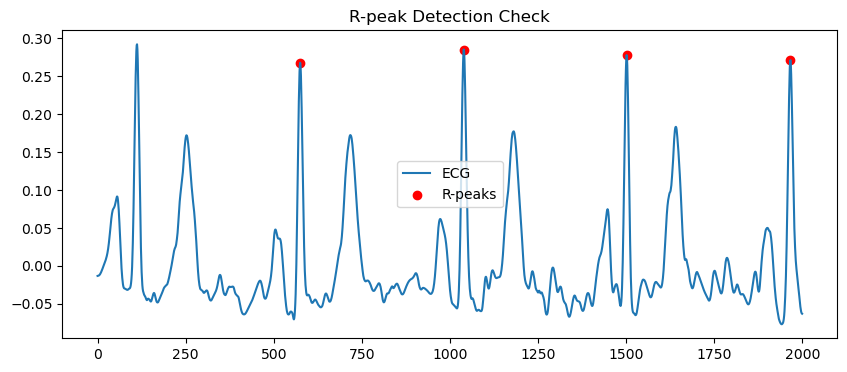


RR INTERVAL STATS:
Mean RR: 0.9397777777777778
Std RR: 0.016691832851745674
Min RR: 0.912
Max RR: 0.964

PEAK COUNT:
Raw: 11
Clean: 10

SIGNAL STD:
Raw std: 0.08595871527169308
Clean std: 0.06937004089297508


In [9]:
# ===== R-PEAK TESTING CELL =====

fs = 500
# use your already loaded sample signal
cleaned_sig = clean_ecg(signal, 500)

# use ONLY one lead (Lead II)
lead = cleaned_sig[1]

# ---- R-PEAK DETECTION ----
_, info = nk.ecg_peaks(lead, sampling_rate=fs)
rpeaks = info["ECG_R_Peaks"]

# ---- VISUAL CHECK ----
plt.figure(figsize=(10,4))
plt.plot(lead[:2000], label="ECG")

rpeaks_vis = [p for p in rpeaks if p < 2000]
plt.scatter(rpeaks_vis, lead[rpeaks_vis], color='red', label="R-peaks")

plt.legend()
plt.title("R-peak Detection Check")
plt.show()

# ---- RR STATS ----
rr = np.diff(rpeaks) / 500

print("\nRR INTERVAL STATS:")
print("Mean RR:", np.mean(rr))
print("Std RR:", np.std(rr))
print("Min RR:", np.min(rr))
print("Max RR:", np.max(rr))

# ---- RAW vs CLEAN COMPARISON ----
_, info_raw = nk.ecg_peaks(signal[:,1], sampling_rate=fs)

print("\nPEAK COUNT:")
print("Raw:", len(info_raw["ECG_R_Peaks"]))
print("Clean:", len(rpeaks))

# ---- SIGNAL QUALITY CHECK ----
print("\nSIGNAL STD:")
print("Raw std:", np.std(signal[:,1]))
print("Clean std:", np.std(lead))

In [10]:
import numpy as np

def extract_hrv_features(rr):
    """
    Extract HRV features from RR intervals

    rr: array of RR intervals (in seconds)

    returns: dict of features
    """

    if rr is None or len(rr) < 2:
        return None

    features = {}

    # ---- BASIC STATS ----
    features["mean_rr"] = np.mean(rr)
    features["std_rr"] = np.std(rr)
    features["min_rr"] = np.min(rr)
    features["max_rr"] = np.max(rr)

    #-------Heart Rate---------
    features["heart_rate"] = 60/features["mean_rr"]

    # ---- HRV FEATURES ----
    diff_rr = np.diff(rr)

    features["rmssd"] = np.sqrt(np.mean(diff_rr**2))  # short-term variability
    features["nn50"] = np.sum(np.abs(diff_rr) > 0.05)  # count of big jumps
    features["pnn50"] = features["nn50"] / len(diff_rr)

    return features

features = extract_hrv_features(rr)

print(features)

{'mean_rr': np.float64(0.9397777777777778), 'std_rr': np.float64(0.016691832851745674), 'min_rr': np.float64(0.912), 'max_rr': np.float64(0.964), 'heart_rate': np.float64(63.844880586427045), 'rmssd': np.float64(0.023291629397704197), 'nn50': np.int64(0), 'pnn50': np.float64(0.0)}


PR mean: 80.80000000000001
QRS mean: 161.6
QT mean: 438.0
R amp: 4.009720017402851
T amp: 2.4333240694476466
PR raw: [0.124 0.04  0.138 0.066 0.058 0.104 0.044 0.158 0.054 0.022]


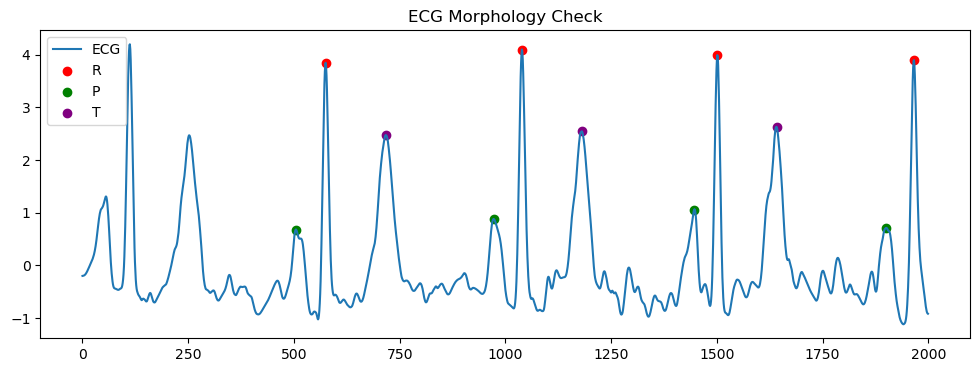

In [11]:
import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt

# load one signal
signal, meta = load_record(path)
cleaned = clean_ecg(signal, 500)
normalized = normalize_ecg(cleaned)

lead = normalized[1]

# process ECG
signals, info = nk.ecg_process(lead, sampling_rate=500)

# delineate waves
_, waves = nk.ecg_delineate(lead, info["ECG_R_Peaks"], sampling_rate=500, method="dwt")

r_onsets = np.array(waves["ECG_R_Onsets"])
p_onsets = np.array(waves["ECG_P_Onsets"])
r_offsets = np.array(waves["ECG_R_Offsets"])
t_offsets = np.array(waves["ECG_T_Offsets"])


# ---------------- FEATURES ---------------- #

pr = (r_onsets - p_onsets) / 500
qrs = (r_offsets - r_onsets) / 500
qt = (t_offsets - r_onsets) / 500

r_amp = lead[info["ECG_R_Peaks"]]
t_amp = lead[waves["ECG_T_Peaks"]]

print("PR mean:", np.nanmean(pr)*1000)
print("QRS mean:", np.nanmean(qrs)*1000)
print("QT mean:", np.nanmean(qt)*1000)
print("R amp:", np.mean(r_amp))
print("T amp:", np.nanmean(t_amp))


# -----------DEBUGGING--------------

print("PR raw:", pr[:20]) # since most of thse are out of therefore, either filter them out or ignore them in the stats

#------------PLOTTING-------------

plt.figure(figsize=(12,4))
plt.plot(lead[:2000], label="ECG")

rpeaks = info["ECG_R_Peaks"]
rpeaks_vis = [p for p in rpeaks if p < 2000]

plt.scatter(rpeaks_vis, lead[rpeaks_vis], color='red', label="R")

# P peaks
p_peaks = waves["ECG_P_Peaks"]
p_vis = [p for p in p_peaks if p < 2000]
plt.scatter(p_vis, lead[p_vis], color='green', label="P")

# T peaks
t_peaks = waves["ECG_T_Peaks"]
t_vis = [p for p in t_peaks if p < 2000]
plt.scatter(t_vis, lead[t_vis], color='purple', label="T")

plt.legend()
plt.title("ECG Morphology Check")
plt.show()

# first wave remains unmarked because it doesnt have the data of its preceding wave - this is refered as 'signal processing edge effect'

Signal shape: (12, 5000)
PR mean: 127.4
QRS mean: 99.66666666666667
QT mean: 394.22222222222223
QTc mean: 406.65724682108817
R amp mean: 4.009720017402851
T amp mean: 2.4333240694476466
ST deviation mean: 0.11681870808534316


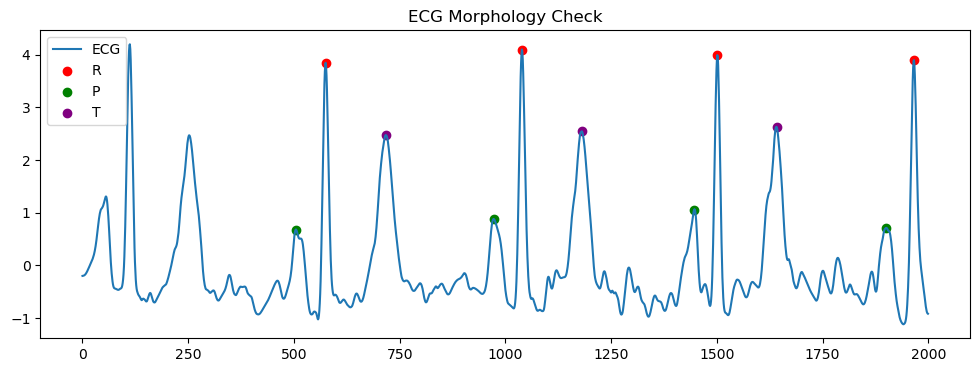

In [12]:
import numpy as np
import neurokit2 as nk

def safe_interval(starts, ends, fs=500, lo_ms=50, hi_ms=600):
    s = np.array(starts, dtype=float)
    e = np.array(ends, dtype=float)
    diff = (e - s) / fs * 1000
    return diff[(diff > lo_ms) & (diff < hi_ms)]

# ---- CHECK SHAPE ----
print("Signal shape:", normalized.shape)

lead = normalized[1] if normalized.shape[0] == 12 else normalized[:, 1]

# ---- PROCESS ----
signals, info = nk.ecg_process(lead, sampling_rate=500)
_, waves = nk.ecg_delineate(lead, info["ECG_R_Peaks"], sampling_rate=500, method="dwt")

# ---- KEYS ----
p_onsets  = waves.get("ECG_P_Onsets", [])
q_peaks   = waves.get("ECG_Q_Peaks", [])
s_peaks   = waves.get("ECG_S_Peaks", [])
t_offsets = waves.get("ECG_T_Offsets", [])
t_peaks   = waves.get("ECG_T_Peaks", [])

# ---- ALIGN LENGTH ----
n = min(len(p_onsets), len(q_peaks), len(s_peaks), len(t_offsets), len(t_peaks))

if n==0:
    print("No valid beats detected")
else:
    p_onsets  = np.array(p_onsets[:n], dtype=float)
    q_peaks   = np.array(q_peaks[:n], dtype=float)
    s_peaks   = np.array(s_peaks[:n], dtype=float)
    t_offsets = np.array(t_offsets[:n], dtype=float)
    t_peaks   = np.array(t_peaks[:n], dtype = float) if len(t_peaks) >= n else np.array([], dtype=float)

    # ---- INTERVALS ----
    pr_ms  = safe_interval(p_onsets, q_peaks,   lo_ms=80,  hi_ms=220)
    qrs_ms = safe_interval(q_peaks,  s_peaks,   lo_ms=40,  hi_ms=130)
    qt_ms  = safe_interval(q_peaks,  t_offsets, lo_ms=250, hi_ms=550)
    
    # ---- QTc (Bazett) ----
    fs = 500
    rr = np.diff(info["ECG_R_Peaks"]) / fs
    rr_mean = np.mean(rr) if len(rr) > 0 else 1
    qtc = qt_ms / np.sqrt(rr_mean)
    
    # ---- AMPLITUDES ----
    r_idx = np.array(info["ECG_R_Peaks"], dtype=float)
    r_idx = r_idx[~np.isnan(r_idx)].astype(int)
    
    t_idx = np.array(t_peaks, dtype = float)
    t_idx = t_idx[~np.isnan(t_idx)].astype(int) if len(t_idx) > 0 else np.array([], dtype=int)
        
    
    # ---- ST DEVIATION (simple approx) ----
    
    valid_pairs = []
    
    for p, q in zip(p_onsets, q_peaks):
        if (
            not np.isnan(p)
            and not np.isnan(q)
        ):
            valid_pairs.append((int(p), int(q)))
    
    
st_values = []

for p, q in valid_pairs:
        
    if p > 10:
        baseline = np.mean(lead[p-10:p])
    else:
        baseline = np.mean(lead)

    st_point = int(q + 0.08 * fs)

    if st_point < len(lead):
        st_values.append(lead[st_point] - baseline)

    # ---- FINAL OUTPUT ----
print("PR mean:", np.mean(pr_ms) if len(pr_ms) > 0 else None)
print("QRS mean:", np.mean(qrs_ms) if len(qrs_ms) > 0 else None)
print("QT mean:", np.mean(qt_ms) if len(qt_ms) > 0 else None)
print("QTc mean:", np.mean(qtc) if len(qtc) > 0 else None)
print("R amp mean:", np.mean(r_amp) if len(r_amp) > 0 else None)
print("T amp mean:", np.mean(t_amp) if len(t_amp) > 0 else None)
print("ST deviation mean:", np.mean(st_values) if len(st_values) > 0 else None)

#------------PLOTTING-------------

plt.figure(figsize=(12,4))
plt.plot(lead[:2000], label="ECG")

rpeaks = info["ECG_R_Peaks"]
rpeaks_vis = [p for p in rpeaks if p < 2000]

plt.scatter(rpeaks_vis, lead[rpeaks_vis], color='red', label="R")

# P peaks
p_peaks = waves["ECG_P_Peaks"]
p_vis = [p for p in p_peaks if p < 2000]
plt.scatter(p_vis, lead[p_vis], color='green', label="P")

# T peaks
t_peaks = waves["ECG_T_Peaks"]
t_vis = [p for p in t_peaks if p < 2000]
plt.scatter(t_vis, lead[t_vis], color='purple', label="T")

plt.legend()
plt.title("ECG Morphology Check")
plt.show()

# first wave remains unmarked because it doesnt have the data of its preceding wave - this is refered as 'signal processing edge effect'

In [27]:
import numpy as np
import neurokit2 as nk
import matplotlib.pyplot as plt

fs = 500

# assume you already have:
# signal (raw loaded)

# ---- CLEAN + NORMALIZE ----
cleaned = clean_ecg(signal, fs)
normalized = normalize_ecg(cleaned)


# ---- SELECT LEAD II ----
lead_norm = normalized[1]
print("Lead len:", len(lead_norm))
lead_raw = cleaned[1]

print("Lead length:", len(lead_norm))
print("NaNs in lead:", np.isnan(lead_norm).sum())

# ---- PROCESS ----
try:
    signals, info = nk.ecg_process(lead_norm, sampling_rate=fs)
except:
    print("No valid beats detected")

_, waves = nk.ecg_delineate(
    lead_norm,
    info["ECG_R_Peaks"],
    sampling_rate=fs,
    method="dwt"
)

# ---- EXTRACT WAVES ----
p_onsets  = np.array(waves.get("ECG_P_Onsets", []), dtype=float)
q_peaks   = np.array(waves.get("ECG_Q_Peaks", []), dtype=float)
s_peaks   = np.array(waves.get("ECG_S_Peaks", []), dtype=float)
t_offsets = np.array(waves.get("ECG_T_Offsets", []), dtype=float)
t_peaks   = np.array(waves.get("ECG_T_Peaks", []), dtype=float)
r_peaks   = np.array(info["ECG_R_Peaks"], dtype=float)


print("R Peaks:", len(info["ECG_R_Peaks"]))
print("P onsets:", len(p_onsets))

# ---- SAFE INTERVAL FUNCTION ----
def safe_interval(starts, ends, fs=500, lo_ms=50, hi_ms=600):
    diff = (ends - starts) / fs * 1000
    valid = (~np.isnan(diff)) & (diff > lo_ms) & (diff < hi_ms)
    return diff[valid]

# ---- INTERVALS ----
pr_ms  = safe_interval(p_onsets, q_peaks, fs, 80, 220)
qrs_ms = safe_interval(q_peaks, s_peaks, fs, 40, 130)
qt_ms  = safe_interval(q_peaks, t_offsets, fs, 250, 550)

# ---- QTc ----
rr = np.diff(r_peaks[~np.isnan(r_peaks)]) / fs
rr_mean = np.mean(rr) if len(rr) > 0 else np.nan
qtc = qt_ms / np.sqrt(rr_mean) if len(qt_ms) > 0 else []

# ---- AMPLITUDES ----
r_idx = r_peaks[~np.isnan(r_peaks)].astype(int)
r_idx = r_idx[r_idx < len(lead_norm)]
r_amp = lead_norm[r_idx]

t_idx = t_peaks[~np.isnan(t_peaks)].astype(int)
t_idx = t_idx[t_idx < len(lead_norm)]
t_amp = lead_norm[t_idx]

# ---- ST DEVIATION ----
st_values = []
for p, q in zip(p_onsets, q_peaks):
    if np.isnan(p) or np.isnan(q):
        continue

    p, q = int(p), int(q)

    baseline_start = max(0, p - 10)
    baseline = np.mean(lead_raw[baseline_start:p]) if p > 0 else 0.0

    st_point = q + int(0.08 * fs)

    if st_point < len(lead_raw):
        st_values.append(lead_raw[st_point] - baseline)

# ---- PRINT FEATURES ----
print("\nFEATURES:")
print("PR mean:", np.mean(pr_ms) if len(pr_ms) > 0 else None)
print("QRS mean:", np.mean(qrs_ms) if len(qrs_ms) > 0 else None)
print("QT mean:", np.mean(qt_ms) if len(qt_ms) > 0 else None)
print("QTc mean:", np.mean(qtc) if len(qtc) > 0 else None)
print("R amp:", np.mean(r_amp) if len(r_amp) > 0 else None)
print("T amp:", np.mean(t_amp) if len(t_amp) > 0 else None)
print("ST mean:", np.mean(st_values) if len(st_values) > 0 else None)

Lead len: 5000
Lead length: 5000
NaNs in lead: 0
R Peaks: 10
P onsets: 10

FEATURES:
PR mean: 127.4
QRS mean: 99.66666666666667
QT mean: 394.22222222222223
QTc mean: 406.65724682108817
R amp: 4.009720017402851
T amp: 2.4333240694476466
ST mean: 0.008103719725131858


In [ ]:
import sys
import os
import pandas as pd
import wfdb  # add this

sys.path.append(os.path.abspath(".."))

from preprocessing.clean import clean_ecg
from preprocessing.normalize import normalize_ecg
from features.rpeak import detect_rpeaks
from features.rr import compute_rr
from features.hrv import extract_hrv_features
from features.morphology import extract_morphology


# ---- PATH ----
base_path = "data/ptb-xl/"
df = pd.read_csv(base_path + "ptbxl_database.csv")
fs = 500
processed_data = []

for i in range(len(df)):
    try:
        row = df.iloc[i]
        record_path = base_path + row["filename_hr"]

        # ---- LOAD ----
        record = wfdb.rdrecord(record_path)
        signal_raw = record.p_signal # shape → (5000, 12), in real mV

        
        # ADD THESE 3 DEBUG LINES
        print(f"record.p_signal shape: {record.p_signal.shape}")
        print(f"signal_raw shape after .T: {signal_raw.shape}")
        print(f"signal_raw dtype: {signal_raw.dtype}")
        
        cleaned = clean_ecg(signal_raw, fs)

        # ---- PREPROCESS ----
        cleaned    = clean_ecg(signal_raw, fs)
        normalized = normalize_ecg(cleaned)

        # ---- LEAD II (index 1) ----
        lead_raw  = cleaned[1]    # real mV — for ST
        lead_norm = normalized[1]    # z-score  — for R-peaks and intervals

        # ---- R PEAKS ----
        rpeaks = detect_rpeaks(normalized, fs)
        if rpeaks is None or len(rpeaks) < 2:
            continue

        # ---- RR ----
        rr = compute_rr(rpeaks, fs)
        rr = rr[(rr > 0.3) & (rr < 2.0)]
        if len(rr) < 2:
            continue

        # ---- HRV ----
        hrv = extract_hrv_features(rr)
        if hrv is None:
            continue

        # ---- MORPHOLOGY ----
        morph = extract_morphology(lead_norm, lead_raw, fs)  # both leads passed
        if morph is None:
            print(f"wrong morphology for record {i}")
            continue

        # ---- HEART RATE ----
        heart_rate = 60 / (rr.mean() / 1000) if rr.mean() > 0 else None

        # ---- COMBINE ----
        combined = {
            "record_id":  i,
            "heart_rate": heart_rate,
            **hrv,
            **morph
        }
        processed_data.append(combined)

        if i < 3:
            print(f"Sample: {combined}")
        if i % 10 == 0:
            print(f"Processed {i} records")

    except Exception as e:
        print(f"Error processing record {i}: {e}")



record.p_signal shape: (5000, 12)
signal_raw shape after .T: (5000, 12)
signal_raw dtype: float64
Lead length: 5000
NaNs: 0
Sample: {'record_id': 0, 'heart_rate': 63.844880586427045, 'mean_rr': 939.7777777777778, 'std_rr': 16.691832851745673, 'min_rr': 912.0, 'max_rr': 964.0, 'rmssd': 23.2916293977042, 'nn50': 0, 'pnn50': 0.0, 'pr_mean': np.float64(127.4), 'qrs_mean': np.float64(99.66666666666667), 'qt_mean': np.float64(394.22222222222223), 'qtc_mean': np.float64(406.65724682108817), 'r_amp_mean': np.float64(4.009720017402851), 't_amp_mean': np.float64(2.4333240694476466), 'st_mean': np.float64(0.008103719725131858)}
Processed 0 records
record.p_signal shape: (5000, 12)
signal_raw shape after .T: (5000, 12)
signal_raw dtype: float64
Lead length: 5000
NaNs: 0
Sample: {'record_id': 1, 'heart_rate': 47.738122300522846, 'mean_rr': 1256.857142857143, 'std_rr': 78.27320025111426, 'min_rr': 1162.0, 'max_rr': 1370.0, 'rmssd': 54.54661614924741, 'nn50': 3, 'pnn50': 0.5, 'pr_mean': np.float64(16

In [31]:
df_features = pd.DataFrame(processed_data)

df_features = df_features.dropna()

df_features.to_csv("data/ptb-xl/processed_features.csv", index=False)

print("Datasaved brooooo")
print(df_features.head())

df_features.describe()

Datasaved brooooo
   record_id  heart_rate      mean_rr     std_rr  min_rr  max_rr      rmssd  \
0          0   63.844881   939.777778  16.691833   912.0   964.0  23.291629   
1          1   47.738122  1256.857143  78.273200  1162.0  1370.0  54.546616   
2          2   63.799622   940.444444  18.397531   916.0   974.0  15.524175   
3          3   75.015628   799.833333  40.410051   732.0   872.0  36.271702   
4          4   66.283694   905.200000  48.639079   830.0   984.0  57.669557   

   nn50     pnn50     pr_mean    qrs_mean     qt_mean    qtc_mean  r_amp_mean  \
0     0  0.000000  127.400000   99.666667  394.222222  406.657247    4.009720   
1     3  0.500000  164.000000   98.000000  400.857143  357.558139    4.527706   
2     0  0.000000  119.750000  101.000000  429.200000  442.633681    4.561276   
3     2  0.181818  140.444444   94.181818  361.818182  404.482894    3.935648   
4     5  0.555556  139.800000  102.571429  376.545455  395.772065    4.913701   

   t_amp_mean   st_m

,record_id,heart_rate,mean_rr,std_rr,min_rr,max_rr,rmssd,nn50,pnn50,pr_mean,qrs_mean,qt_mean,qtc_mean,r_amp_mean,t_amp_mean,st_mean
count,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000,95.000000
mean,50.747368,71.375674,870.893565,43.821195,787.852632,929.221053,49.232725,1.968421,0.233421,143.458025,92.471958,380.483497,411.223541,4.384911,1.677240,0.045832
std,29.178456,14.626206,159.151397,29.028660,152.971487,177.619075,38.285429,2.160834,0.264206,18.199426,14.789683,34.353238,27.412647,1.183802,0.628789,0.209219
min,0.000000,45.731707,395.416667,2.098182,322.000000,432.000000,2.160247,0.000000,0.000000,102.666667,57.272727,317.866667,350.262205,0.340452,-0.166831,-0.985771
25%,26.500000,62.298191,772.287879,19.067648,676.000000,807.000000,20.938248,0.000000,0.000000,130.327273,81.285714,357.666667,393.890971,3.980006,1.282900,-0.063458
50%,52.000000,69.196897,867.090909,39.152746,792.000000,914.000000,38.162809,1.000000,0.111111,142.222222,94.000000,376.727273,407.799179,4.648402,1.703609,0.017636
75%,75.500000,77.692131,963.111111,59.961302,893.000000,1029.000000,64.028301,3.000000,0.428571,157.714286,102.558442,401.044444,426.173207,5.267849,2.176582,0.135406
max,99.000000,151.738672,1312.000000,136.589714,1210.000000,1400.000000,191.335656,9.000000,1.000000,184.750000,120.000000,462.800000,511.723055,6.195907,3.165202,0.705764
